In [9]:
import sys
import numpy as np
import time
from tqdm import tqdm_notebook as tqdm
import random
# !{sys.executable} -m pip install tqdm

In [10]:
from heapq import heapify, heappop, heappush, heapreplace, nlargest, nsmallest

class KGraph(object): 
    def __init__(self, k, dim, dist_func, data):
        self.distance_func = dist_func
        self.k = k
        self.dim = dim
        self.count_brute_force_search = 0
        self.count_greedy_search = 0
        self.data = data
        # build k-graph by brute force knn-search
        print('Building k-graph')
        self.edges = []
        for x in tqdm(self.data):
            self.edges.append(self.brute_force_knn_search(self.k+1, x)[1:])
        self.reset_counters()

    def beam_search(self, q, k, eps, ef, ax=None, marker_size=20, observed=False):
        '''
        q - query
        k - number of closest neighbors to return
        eps – entry points [vertex_id, ..., vertex_id]
        ef – size of the beam
        observed – if True returns the full of elements for which the distance were calculated
        returns – a list of tuples [(vertex_id, distance), ... , ]
        '''
        # Priority queue: (negative distance, vertex_id)
        candidates = []
        visited = set()  # set of vertex used for extending the set of candidates
        observed = dict() # dict: vertex_id -> float – set of vertexes for which the distance were calculated

        if ax:
            ax.scatter(x=q[0], y=q[1], s=marker_size, color='red', marker='^')
            ax.annotate('query', (q[0], q[1]))

        # Initialize the queue with the entry points
        for ep in eps:
            dist = self.distance_func(q, self.data[ep])
            heappush(candidates, (dist, ep))
            observed[ep] = dist

        while candidates:
            # Get the closest vertex (furthest in the max-heap sense)
            dist, current_vertex = heappop(candidates)

            if ax:
                ax.scatter(x=self.data[current_vertex][0], y=self.data[current_vertex][1], s=marker_size, color='red')
                ax.annotate( len(visited), self.data[current_vertex] )

            # check stop conditions #####
            observed_sorted = sorted( observed.items(), key=lambda a: a[1] )
            # print(observed_sorted)
            ef_largets = observed_sorted[ min(len(observed)-1, ef-1 ) ]
            # print(ef_largets[0], '<->', -dist)
            if ef_largets[1] < dist:
                break
            #############################

            # Add current_vertex to visited set
            visited.add(current_vertex)

            # Check the neighbors of the current vertex
            for neighbor, _ in self.edges[current_vertex]:
                if neighbor not in observed:
                    dist = self.distance_func(q, self.data[neighbor])                    
                    # if neighbor not in visited:
                    heappush(candidates, (dist, neighbor))
                    observed[neighbor] = dist                    
                    if ax:
                        ax.scatter(x=self.data[neighbor][0], y=self.data[neighbor][1], s=marker_size, color='yellow')
                        # ax.annotate(len(visited), (self.data[neighbor][0], self.data[neighbor][1]))
                        ax.annotate(len(visited), self.data[neighbor])
                    
        
        # Sort the results by distance and return top-k
        observed_sorted =sorted( observed.items(), key=lambda a: a[1] )
        if observed:
            return observed_sorted
        return observed_sorted[:k]

    def reset_counters(self):
        self.count_brute_force_search = 0
        self.count_greedy_search = 0
    
    def l2_distance(a, b):
        return np.linalg.norm(a - b)
    def _vectorized_distance(self, x, ys):
        return [self.distance_func(x, y) for y in ys]

    def brute_force_knn_search(self, k, x):
        '''
        Return the list of (idx, dist) for k-closest elements to {x} in {data}
        '''
        self.count_brute_force_search = self.count_brute_force_search + 1
        return sorted(enumerate(self._vectorized_distance(x, self.data)), key=lambda a: a[1])[:k]

    def plot_graph(self, ax, color, linewidth=0.5):        
        ax.scatter(self.data[:, 0], self.data[:, 1], c=color)
        for i in range(len(self.data)):
            for edge_end in self.edges[i]:
                ax.plot( [self.data[i][0], self.data[edge_end][0]], [self.data[i][1], self.data[edge_end][1]], c=color, linewidth=linewidth )

In [11]:
dim = 2
n = 200
data_a = np.array(np.float32(np.random.random((n, dim))))
data_b = np.array(np.float32(np.random.random((n, dim))))

In [12]:
k = 5
kga = KGraph(k=k, dim=dim, dist_func=KGraph.l2_distance, data=data_a)
kgb = KGraph(k=k, dim=dim, dist_func=KGraph.l2_distance, data=data_b)

Building k-graph


/var/folders/d6/l74bp05x30146zch7ch0yd040000gn/T/ipykernel_97499/3501787423.py:14: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for x in tqdm(self.data):


  0%|          | 0/200 [00:00<?, ?it/s]

Building k-graph


  0%|          | 0/200 [00:00<?, ?it/s]

In [532]:
# fig, ax = plt.subplots(figsize=(10, 8), dpi=120) 
# kga.plot_graph(ax, color='blue', linewidth=0.2)
# kgb.plot_graph(ax, color='green', linewidth=0.2)
# cadidates_2 = kgb.beam_search(q=kgb.data[6], k=5, eps=[0,50,100,150], ef=5, ax=ax, marker_size=30, )

# Now it is a time to merge 2 k-graphs

# Algorithm 1
- Version with no filter-beam-search
- Compexity O(N + M). Additional space on disk O(N + M)

In [539]:
import random
merged_edges = [ None for i in range(len(kga.data) + len(kgb.data) ) ]
merged_data = np.concatenate((kga.data , kgb.data ), axis=0)

currents = [] # sequence of steps for visualisation
observed_steps = [] # the of elements for which the distance were calculated on a particular step

def merge(kga, kgb, ine_flag, search_ef=5, next_step_k=1, next_step_ef=5, M = 5):
    '''
    kga          – first graph 
    kgb          – second graph
    inverse_flat – True if graphs are passed in inverse order
    search_ef    - ef parameter for searching candidates in the second graph
    next_step_k  - at each iteration we look for the next element around the current vertex in the first graph. 
                   However it can be surrounded by the "done" vertex, so we have to walk away. 
                   Thus this parameter controlls how far from the current vertex we can go.
    next_step_ef – a purpose of this parameter is similar {next_step_k}
    M            – nunber of starting random enterpoints for beam_search
                  
    '''
    not_done = set( range(len(kga.data)) )
    shift = len(kga.data)
    reverse_shift = 0
    if inverse_flag:
        shift = 0
        reverse_shift = len(kgb.data)
        
    while not_done:
        curr_idx = not_done.pop()
        print(f'jump to {curr_idx}')
    
        # enter_points = [0,50,100,150] # TODO select M random points of kgb
        enter_points = random.sample(range(len(kgb.data)), M)
        
        while True:
            currents.append(curr_idx + reverse_shift)
            observed = kgb.beam_search(kga.data[curr_idx], k, eps=enter_points, ef=search_ef, observed=True)
            # observed_steps.append(observed)
            observed_steps.append([ (idx+shift, dist) for idx, dist in observed])
            cadidates_b = observed[:k]
            # == build neighborhood for curr_idx and save to externalset of edges  ==
            merged_edges[curr_idx + reverse_shift] = sorted ([ (idx_b+ shift, dist) for idx_b, dist in cadidates_b] + [ (idx + reverse_shift, dist) for idx, dist in kga.edges[curr_idx]], key=lambda a: a[1])[:k]
            # == == == == == == == == == == == == == == == == == == == == == == == ==
    
            enter_points = [idx for idx, dist in cadidates_b] # ! determine a new set of enter_points for search on kgb
            
            candidates_a = kga.beam_search(kga.data[curr_idx], next_step_k, [ curr_idx], ef=next_step_ef) # decrease k to traverse closer to curr vertex
            candidates_a = [c[0] for c in candidates_a if c[0] in not_done]
    
            if not candidates_a:
                break
            curr_idx = candidates_a[0]
            not_done.remove(curr_idx)

merge(kga, kgb, inverse_flag=False) # phase 1
merge(kgb, kga, inverse_flag=True) # phase 2

jump to 0
jump to 1
jump to 2
jump to 4
jump to 5
jump to 9
jump to 11
jump to 21
jump to 38
jump to 39
jump to 40
jump to 55
jump to 65
jump to 141
jump to 164
jump to 169
jump to 174
jump to 179
jump to 0
jump to 1
jump to 2
jump to 3
jump to 14
jump to 16
jump to 28
jump to 39
jump to 76
jump to 99
jump to 113
jump to 128


## Visualisation

/var/folders/d6/l74bp05x30146zch7ch0yd040000gn/T/ipykernel_62732/2314580521.py:40: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  ani = FuncAnimation(fig, update, frames=tqdm(range(len(merged_data))))


  0%|          | 0/400 [00:00<?, ?it/s]

MovieWriter ffmpeg unavailable; using Pillow instead.


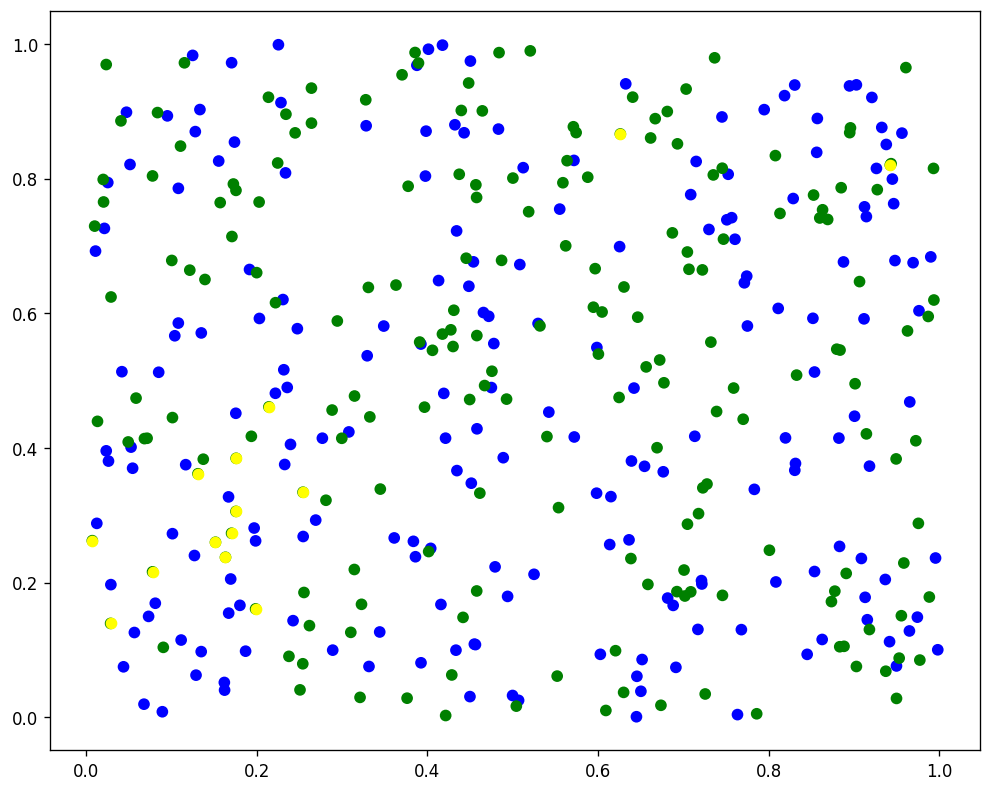

In [540]:
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8), dpi=120)

# scat = ax.scatter(kga.data[:, 0], kga.data[:, 1], c='blue')
def update(frame):    
    ax.clear()
    # kga.plot_graph(ax, color='blue', linewidth=0.2)
    
    not_done = set(range(len(merged_data)))
    for i in range(frame):
        not_done.remove(currents[i])
    
    colors = ['blue' if i in not_done else 'black' for i in range(len(kga.data))]
    colors = colors + ['green' if i in not_done else 'black' for i in range(len(kga.data),len(merged_data))]
    
    # kga.plot_graph(ax, color='blue', linewidth=0.2)    
    ax.scatter(merged_data[:, 0], merged_data[:, 1], c=colors)

    for vertex_id, dist in observed_steps[frame]:
        ax.scatter(merged_data[vertex_id][0], merged_data[vertex_id][1], c='yellow')
    
    for i in range(frame):
        for edge_end, dist in merged_edges[currents[i]]:
            ax.plot( [merged_data[currents[i]][0], merged_data[edge_end][0]], [merged_data[currents[i]][1], merged_data[edge_end][1]], c= 'blue' if edge_end < len(kga.data) else 'green' )
        
    return fig, ax
ani = FuncAnimation(fig, update, frames=tqdm(range(len(merged_data))))
ani.save("merging-alg1-1.gif", fps=10)

![Algorithm1](merging-alg1.gif "Merging Graphs - Algorithm 1")

# Algorithm 2 -- In progress
Time complexity $\theta (n+m)$; Space $O(1)$

In [ ]:
merged_data = kga.data + kgb.data
merged_edges = [ None for i in range(len(kga.data) + len(kgb.data) ) ]
while (len(not_done_a) > 0) or (len(not_done_b) > 0):
    if (len(not_done) > 0):
        a = not_done_a.pop()
        a_candidates = [ i for i in kba.edges[a] ]
        b_candidates = [ (len(kga.data) + i) for i, dist in kgb.brute_force_knn_search(kgb.k, a)]]
        
        candidates = a_candidates + b_candidates
        knn = [y for dist, y in sorted( [(kgb.distance_func(kga.data[a], merged_data[i]), i) for i in candidates])][:k]
        merged_edges[a] = knn 
        done.add(a)
        # now the work is done for element {a}
        # lets do the same for the closest element of {a} with a hope that 
        nexts = [i for i in knn if i not in done]
        if not nexts:
            continue
        _next = nexts[0]

        
            

In [72]:
if not []:
    print('True')

True


In [ ]:
def step(curr, candidates, T, kga, kgb, M=1):
    '''
    curr – an element for which the neighborhood should be built
    candidates: [ (element_id , age), ..., (element_id, age)]
    T – inversion flag. Flase – no inversion, True - the graphs are passed in reverse order
    kga - graph "A"
    kgb - graph "B"
    M - how many previous steps are memorised 
    '''
    a_candidates = [ i for i in kba.edges[a] ] 
    b_candidates = [ (len(kga.data) + i, 0) for i in kgb.brute_force_knn_search(kgb.k, a)]]
    candidates = a_candidates + b_candidates
    knn = [y for dist, y in sorted( [(kgb.distance_func(kga.data[a], merged_data[i]), i) for i in candidates])][:k]
    merged_edges[a] = knn 
    done.add(a)
    # now the work is done for element {a}
    # lets do the same for the closest element of {a} with a hope that 
    nexts = [i for i in knn if i not in done]
    if not nexts:
        continue
    _next = nexts[0]


    # forgot the candidates that are older than {M}
    # add new candidates

In [22]:
def calculate_recall(kg, test, k, ef, M):
    recalls = []
    for query in tqdm(test):
        # Perform brute force search to get true neighbors
        true_neighbors = [neighbor for neighbor, dist in kg.brute_force_knn_search(k, query)]  # skip self
        # Perform beam search
        entry_points = random.sample(range(len(kgb.data)), M) # Start with a random entry point
        searched_neigbors = [neighbor for neighbor, dist in kg.beam_search(query, k, entry_points, ef)]
        # Calculate recall as the intersection of true neighbors and beam search neighbors
        intersection = len(set(true_neighbors).intersection(set(searched_neigbors)))
        recall = intersection / k
        recalls.append(recall)
    
    # Return the average recall
    return np.mean(recalls)

In [27]:
calculate_recall(kg=kga, test=data_b, k=5, ef=11, M=2)

/var/folders/d6/l74bp05x30146zch7ch0yd040000gn/T/ipykernel_97499/2116247745.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for query in tqdm(test):


  0%|          | 0/200 [00:00<?, ?it/s]

np.float64(0.7909999999999999)